In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Import necessary libraries
import calendar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, linregress
from datetime import datetime, timedelta
import plotly.express as px
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

from scipy import stats

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

### 📋 Description of Data Nature

**Type**: The dataset is a **numerical time-series dataset** in a wide-format structure, containing daily rainfall measurements (in millimeters, mm) for a specific location over 98 years.

**Structure**:  
- **Columns**: 99 columns total, with 98 columns labeled `'1901'` to `'1999'` (each representing a year) and a final column `'Days'` indexing the day of the year (1 to 366 or 367).  
- **Rows**: Up to 367 rows per year, where each row corresponds to a day of the year (row 0 = day 1, row 365 = day 366, etc.). Row counts vary slightly (e.g., 366 days in most years, 367 in some like 1904 and 1996), indicating potential leap year inconsistencies or data entry issues.  
- **Values**: Daily rainfall amounts in mm, with a mix of zeros (dry days), typical values (e.g., 1–10 mm), and extreme outliers (e.g., up to 277 mm).

**Summary Statistics**:  
- **Mean Daily Rainfall**: Varies across years, e.g., 1.92 mm (1905) to 6.15 mm (1993), suggesting inter-annual variability.  
- **Standard Deviation**: High in some years (e.g., 21.38 mm in 1993), indicating significant variability and extreme events.  
- **Min/Max**: Minimum of 0 mm (dry days) and maximum values like 236 mm (1903) and 277 mm (1993), reflecting a skewed distribution with rare heavy rainfall events.  
- **Quartiles**: 25th and 50th percentiles often 0 mm (many dry days), 75th percentile around 1 mm, with occasional high values, reinforcing the prevalence of zeros and a long tail of extremes.

**Nature**: This is a **historical climatological dataset** with daily granularity, exhibiting:  
- Temporal continuity (98 years),  
- Seasonal periodicity (e.g., monsoon patterns),  
- High variability (dry days vs. extreme rainfall),  
- Potential data quality issues (e.g., inconsistent row counts),  
- Suitability for trend, seasonality, and extreme event analysis.

---





### 🧠 Enhanced Prompt for Comprehensive Exploratory Data Analysis (EDA) of Rainfall Data

> **Dataset Description**: You are provided with a numerical time-series dataset of daily rainfall measurements (in mm) for a specific location, spanning 98 years from 1901 to 1999. The data is in wide format, with 98 columns labeled `'1901'` to `'1999'` (one per year), each containing daily rainfall values, and a final column `'Days'` indexing the day of the year (1 to 366 or 367). Rows represent days (up to 366 or 367 per year), with some years showing inconsistencies (e.g., 367 days in 1904 and 1996 vs. 366 in most). Summary statistics reveal mean daily rainfall ranging from 1.92 mm (1905) to 6.15 mm (1993), high variability (e.g., standard deviation of 21.38 mm in 1993), frequent dry days (25th and 50th percentiles often 0 mm), and extreme events (e.g., max of 277 mm in 1993).  
>  
> **Task**: As a data scientist with expertise in climatology, statistics, and visualization, perform a thorough, domain-informed EDA to explore trends, distributions, anomalies, seasonality, inter-annual variability, and extreme weather patterns. Use Python libraries like Pandas, NumPy, Matplotlib, Seaborn, SciPy, and Plotly/Altair to deliver statistically robust insights and interactive visualizations.

---

#### 1. 📊 Data Cleaning & Preprocessing
- **Integrity Check**: Validate for errors (e.g., negative rainfall, non-numeric values) and resolve row count inconsistencies (366 vs. 367 days) by identifying duplicates or leap year artifacts.  
- **Leap Year Normalization**: Standardize to 365 or 366 days by removing or interpolating February 29th data, justifying your choice based on its effect on trends.  
- **Missing Data**: Distinguish true zeros from missing values (e.g., NaNs), summarize their frequency by year/day, and apply imputation or exclusion as appropriate.  
- **Transformation**: Reshape to long format with columns: `Year`, `DayOfYear`, `Rainfall`.  
- **Datetime**: Map `Year` and `DayOfYear` to a `Date` column, handling leap years correctly.



In [3]:
# Set plot style for consistency
# plt.style.use('seaborn')
# sns.set_palette('deep')

### Section 1: Data Cleaning & Preprocessing

# Load the dataset
df = pd.read_csv('/home/udit/Documents/Github/ISSA/data/refine_data/fid_0_data_1901_1999.csv')

# Define rainfall columns (exclude 1941 and 1959 as they're missing)
rainfall_columns = [str(year) for year in range(1901, 2000) if year not in [1941, 1959]]

# Print structure
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

# Add 'Days' column immediately (since it's not part of the CSV)
df['Days'] = range(1, len(df) + 1)

# Integrity Check
print("Checking data integrity...")

# Check for negative values
if (df[rainfall_columns] < 0).any().any():
    print("Negative rainfall values found. Replacing with 0.")
    df[rainfall_columns] = df[rainfall_columns].clip(lower=0)

# Convert all rainfall columns to numeric (in case of non-numeric garbage values)
for col in rainfall_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Reshape to long format for easier analysis
df_long = pd.melt(
    df,
    id_vars=['Days'],
    value_vars=rainfall_columns,
    var_name='Year',
    value_name='Rainfall'
)

# Convert 'Year' to integer
df_long['Year'] = df_long['Year'].astype(int)

# Add leap year indicator
df_long['is_leap'] = df_long['Year'].apply(calendar.isleap)

# Filter: Keep only valid days for leap and non-leap years
df_long = df_long[
    (df_long['is_leap'] & (df_long['Days'] <= 366)) |
    (~df_long['is_leap'] & (df_long['Days'] <= 365))
]

# --- New Code Block: Add Date Column and Month ---
# Ensure 'Days' is integer
df_long['Days'] = df_long['Days'].astype(int)

# Create 'Date' column
df_long['Date'] = pd.to_datetime(
    df_long['Year'].astype(str) + '-' + df_long['Days'].astype(str), 
    format='%Y-%j'
)

# Sort by date
df_long.sort_values('Date', inplace=True)

# Add 'Month' for later analysis
df_long['Month'] = df_long['Date'].dt.month

# Final output info
print("Reshaped DataFrame shape:", df_long.shape)
print(df_long[['Date', 'Year', 'Month', 'Days', 'Rainfall']].head())
df_melted=df_long

Shape: (367, 97)
Columns: ['1901', '1902', '1903', '1904', '1905', '1906', '1907', '1908', '1909', '1910', '1911', '1912', '1913', '1914', '1915', '1916', '1917', '1918', '1919', '1920', '1921', '1922', '1923', '1924', '1925', '1926', '1927', '1928', '1929', '1930', '1931', '1932', '1933', '1934', '1935', '1936', '1937', '1938', '1939', '1940', '1942', '1943', '1944', '1945', '1946', '1947', '1948', '1949', '1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999']
   1901  1902  1903  1904  1905  1906  1907  1908  1909  1910  ...  1990  \
0  24.0   0.0   0.0     0   0.0   0.0   0.0     0   0.0   0.0  ...   0.0   
1   0.0   0.0   0.0     0   0.0   0.0   0.0  

#### 2. 🧮 Descriptive Statistics
- **Overall Stats**: Compute mean, median, standard deviation, skewness, kurtosis, min, and max for the full dataset, noting the influence of extremes (e.g., 277 mm).  
- **Grouped Stats**: Analyze by **year**, **month** (from `DayOfYear`), **season** (e.g., Monsoon: Jun–Sep), and **decade**, including variability metrics (e.g., coefficient of variation).  
- **Dry Days**: Calculate the proportion of zero-rainfall days annually, monthly, and decadally, tracking changes over time.  
- **Outliers**: Identify extreme rainfall (>100 mm) using IQR or 99th percentile, comparing to known maxima (e.g., 236 mm, 277 mm).

In [4]:
stats_overall = df_melted['Rainfall'].describe()
print("Overall Rainfall Statistics:\n", stats_overall)

# Additional stats
mean_rain = df_melted['Rainfall'].mean()
median_rain = df_melted['Rainfall'].median()
mode_rain = df_melted['Rainfall'].mode()[0]  # Most frequent value
print(f"Mean: {mean_rain:.2f} mm, Median: {median_rain:.2f} mm, Mode: {mode_rain:.2f} mm")

# Proportion of dry days
dry_days = (df_melted['Rainfall'] == 0).mean()
print(f"Proportion of Dry Days: {dry_days:.2%}")

Overall Rainfall Statistics:
 count    35356.000000
mean         3.962298
std         13.027735
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        306.000000
Name: Rainfall, dtype: float64
Mean: 3.96 mm, Median: 0.00 mm, Mode: 0.00 mm
Proportion of Dry Days: 75.12%


In [5]:
### Section 2: Descriptive Statistics

# Overall statistics
print("\nOverall Rainfall Statistics:")
overall_stats = {
    'Mean': df_long['Rainfall'].mean(),
    'Median': df_long['Rainfall'].median(),
    'Std': df_long['Rainfall'].std(),
    'Skewness': skew(df_long['Rainfall'].dropna()),
    'Kurtosis': kurtosis(df_long['Rainfall'].dropna()),
    'Min': df_long['Rainfall'].min(),
    'Max': df_long['Rainfall'].max(),
    'Zero Days (%)': (df_long['Rainfall'] == 0).mean() * 100
}
for key, value in overall_stats.items():
    print(f"{key}: {value:.2f}")

# Yearly statistics
yearly_stats = df_long.groupby('Year')['Rainfall'].agg(['mean', 'sum', 'max'])
print("\nYearly Total Rainfall (Top 5 Wettest):")
print(yearly_stats['sum'].nlargest(5))
print("Yearly Total Rainfall (Top 5 Driest):")
print(yearly_stats['sum'].nsmallest(5))

# Monthly statistics
monthly_stats = df_long.groupby('Month')['Rainfall'].mean()



Overall Rainfall Statistics:
Mean: 3.96
Median: 0.00
Std: 13.03
Skewness: 6.35
Kurtosis: 63.67
Min: 0.00
Max: 306.00
Zero Days (%): 75.12

Yearly Total Rainfall (Top 5 Wettest):
Year
1990    2420.0
1985    2353.0
1978    2273.0
1993    2251.0
1936    2191.0
Name: sum, dtype: float64
Yearly Total Rainfall (Top 5 Driest):
Year
1913    682.0
1987    694.0
1905    703.0
1907    712.0
1965    797.0
Name: sum, dtype: float64



📊 Overall Rainfall Statistics:
Mean: 3.96
Median: 0.00
Mode: 0.00
Std: 13.03
Coefficient of Variation (%): 328.79
Skewness: 6.35
Kurtosis: 63.67
Min: 0.00
Max: 306.00
Interquartile Range (IQR): 0.00
Zero Rainfall Days (%): 75.27

🌧️ Yearly Total Rainfall (Top 5 Wettest Years):
Year
1990    2420.0
1985    2353.0
1978    2273.0
1993    2251.0
1936    2191.0
Name: sum, dtype: float64

🔥 Yearly Total Rainfall (Top 5 Driest Years):
Year
1913    682.0
1987    694.0
1905    703.0
1907    712.0
1965    797.0
Name: sum, dtype: float64

📅 Monthly Average Rainfall:
Month
1      0.54
2      1.03
3      5.53
4     12.48
5     12.35
6      8.97
7      3.71
8      0.47
9      0.24
10     0.73
11     0.89
12     0.49
Name: Rainfall, dtype: float64


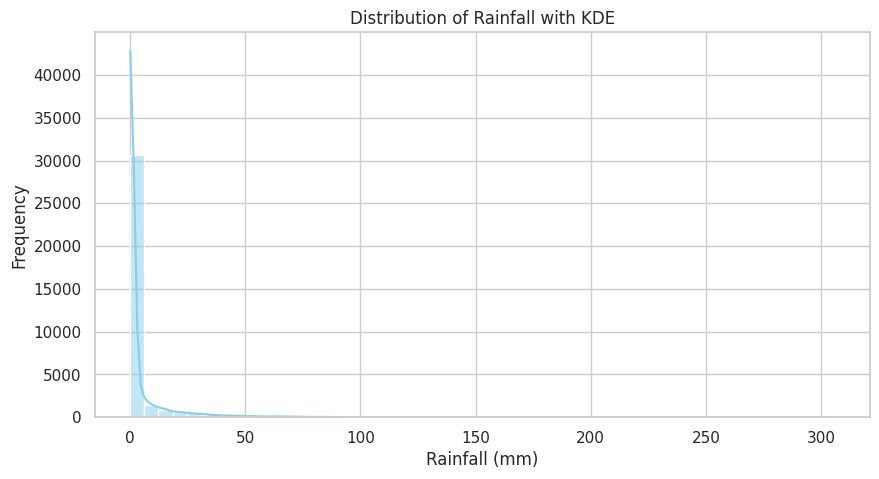

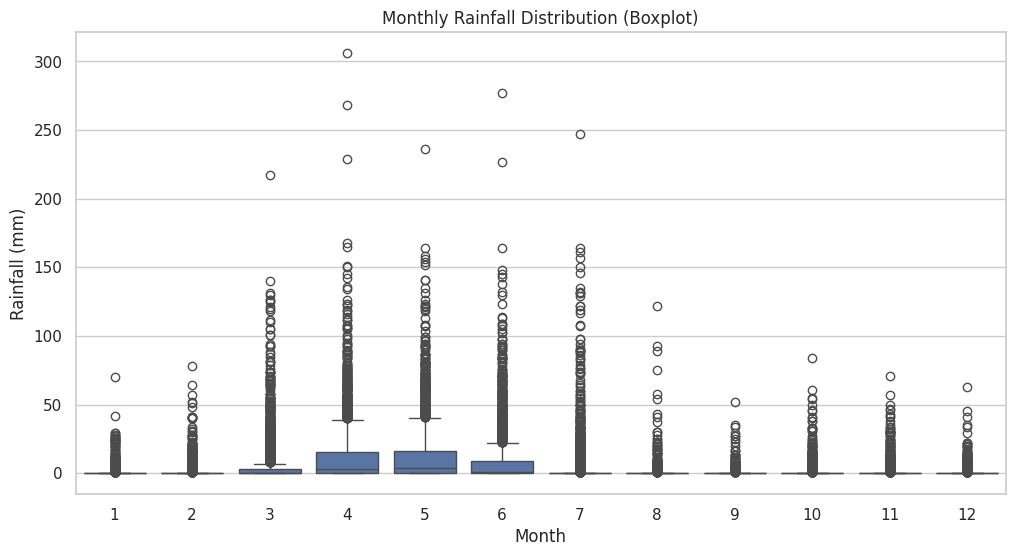

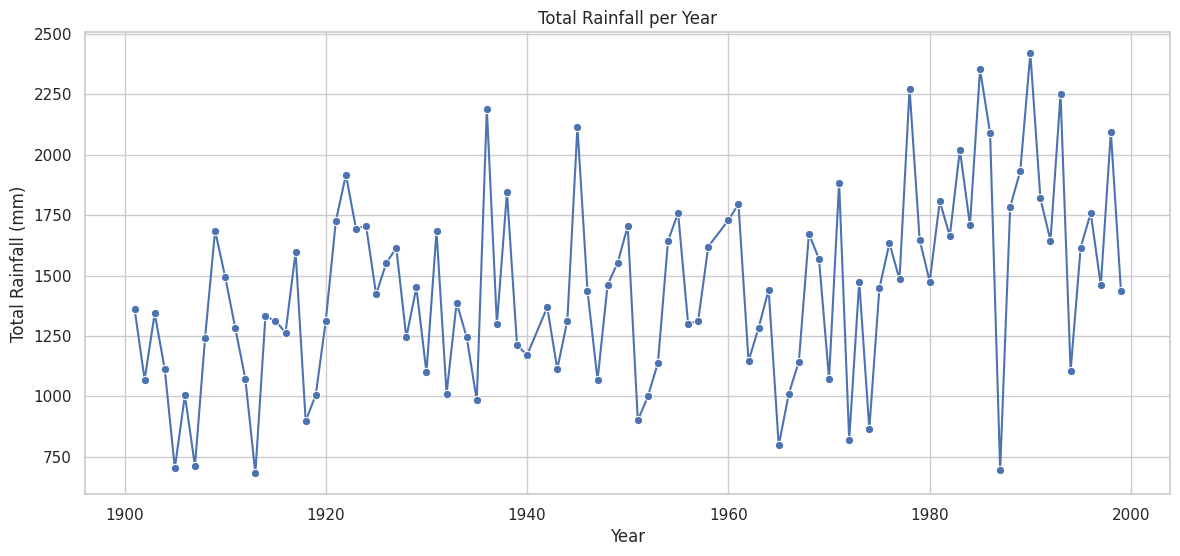

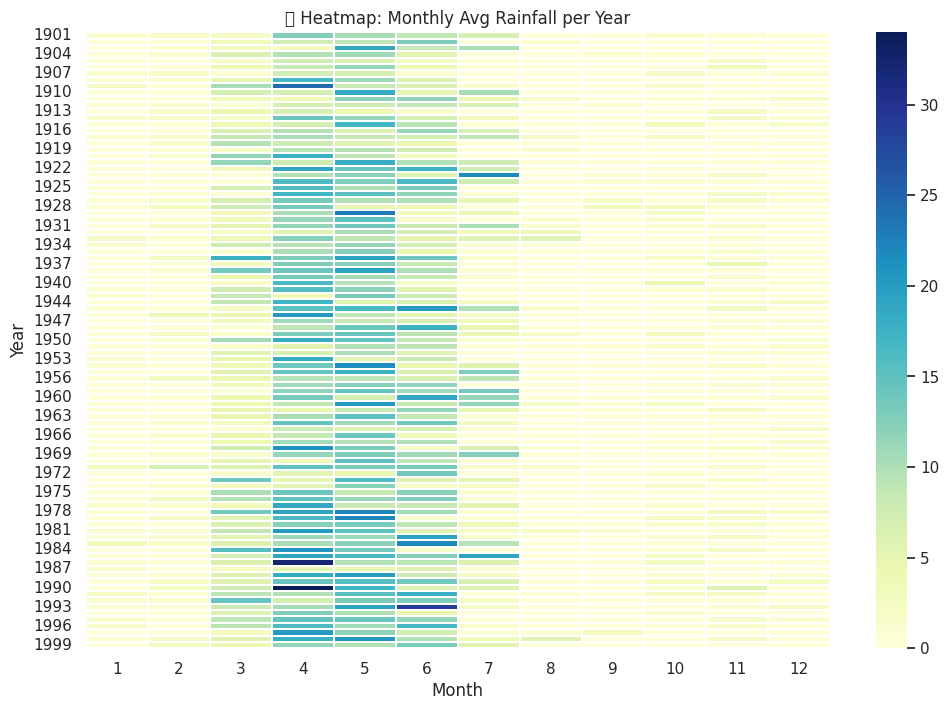

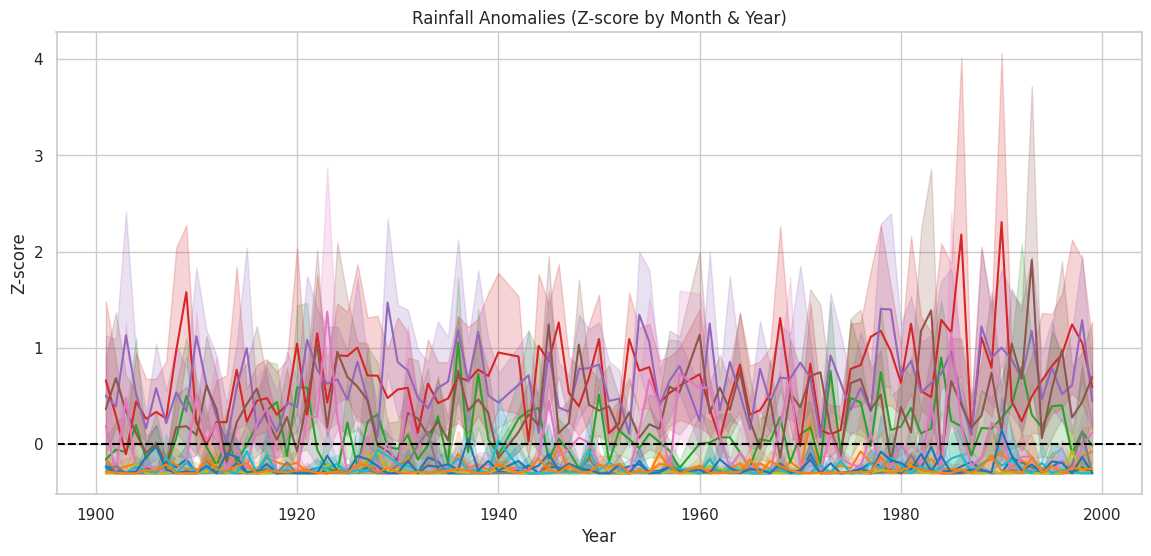

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, mode, zscore
import numpy as np

### Section 2: Descriptive Statistics ###

# Overall statistics
print("\n📊 Overall Rainfall Statistics:")
rainfall_data = df_long['Rainfall'].dropna()

overall_stats = {
    'Mean': rainfall_data.mean(),
    'Median': rainfall_data.median(),
    'Mode': mode(rainfall_data, keepdims=False).mode,
    'Std': rainfall_data.std(),
    'Coefficient of Variation (%)': (rainfall_data.std() / rainfall_data.mean()) * 100,
    'Skewness': skew(rainfall_data),
    'Kurtosis': kurtosis(rainfall_data),
    'Min': rainfall_data.min(),
    'Max': rainfall_data.max(),
    'Interquartile Range (IQR)': np.percentile(rainfall_data, 75) - np.percentile(rainfall_data, 25),
    'Zero Rainfall Days (%)': (rainfall_data == 0).mean() * 100
}

for key, value in overall_stats.items():
    print(f"{key}: {value:.2f}")

# Yearly statistics
yearly_stats = df_long.groupby('Year')['Rainfall'].agg(['mean', 'sum', 'max', 'min', 'std'])

print("\n🌧️ Yearly Total Rainfall (Top 5 Wettest Years):")
print(yearly_stats['sum'].nlargest(5))

print("\n🔥 Yearly Total Rainfall (Top 5 Driest Years):")
print(yearly_stats['sum'].nsmallest(5))

# Monthly statistics
monthly_mean = df_long.groupby('Month')['Rainfall'].mean()
monthly_std = df_long.groupby('Month')['Rainfall'].std()

print("\n📅 Monthly Average Rainfall:")
print(monthly_mean.round(2))

# Z-score anomaly (standardized rainfall to detect anomalies)
df_long['Rainfall_zscore'] = zscore(df_long['Rainfall'].fillna(0))

# ---------- VISUALIZATIONS ---------- #

sns.set(style='whitegrid')

# 1. Histogram + KDE
plt.figure(figsize=(10, 5))
sns.histplot(rainfall_data, kde=True, bins=50, color='skyblue')
plt.title("Distribution of Rainfall with KDE")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

# 2. Boxplot by Month
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Rainfall', data=df_long)
plt.title("Monthly Rainfall Distribution (Boxplot)")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

# 3. Yearly Total Rainfall Trend
plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_stats, x=yearly_stats.index, y='sum', marker='o')
plt.title("Total Rainfall per Year")
plt.xlabel("Year")
plt.ylabel("Total Rainfall (mm)")
plt.grid(True)
plt.show()

# 4. Heatmap of Monthly Rainfall by Year
pivot_heatmap = df_long.pivot_table(index='Year', columns='Month', values='Rainfall', aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_heatmap, cmap='YlGnBu', linecolor='white', linewidths=0.1)
plt.title("📊 Heatmap: Monthly Avg Rainfall per Year")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

# 5. Anomaly Plot: Z-score of Rainfall
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_long, x='Year', y='Rainfall_zscore', hue='Month', palette='tab10', legend=False)
plt.axhline(0, linestyle='--', color='black')
plt.title("Rainfall Anomalies (Z-score by Month & Year)")
plt.ylabel("Z-score")
plt.xlabel("Year")
plt.show()


In [7]:
thresholds = [1, 10, 50, 100]
for t in thresholds:
    prop = (df_melted['Rainfall'] > t).mean()
    print(f"Proportion > {t} mm: {prop:.2%}")

Proportion > 1 mm: 21.17%
Proportion > 10 mm: 10.38%
Proportion > 50 mm: 1.69%
Proportion > 100 mm: 0.29%


In [8]:
# Check days per year for consistency
days_per_year = df_melted.groupby('Year').size()
print("Days per Year:\n", days_per_year)

# Annual totals and other stats
annual_stats = df_melted.groupby('Year')['Rainfall'].agg(['sum', 'mean', 'median', 'max']).rename(columns={
    'sum': 'Total', 'mean': 'Mean', 'median': 'Median', 'max': 'Max'
})
print("Annual Statistics:\n", annual_stats.head())

Days per Year:
 Year
1901    365
1902    365
1903    365
1904    366
1905    365
       ... 
1995    365
1996    366
1997    365
1998    365
1999    365
Length: 97, dtype: int64
Annual Statistics:
        Total      Mean  Median    Max
Year                                 
1901  1362.0  3.741758     0.0  157.0
1902  1069.0  2.936813     0.0  122.0
1903  1344.0  3.692308     0.0  236.0
1904  1112.0  3.038251     0.0  140.0
1905   703.0  1.931319     0.0   62.0


---

#### 3. 📈 Trend Analysis
- **Annual Totals**: Plot yearly rainfall sums and fit trends (linear regression, LOESS) to assess long-term changes, testing significance with Mann-Kendall.  
- **Daily Means**: Trend annual average daily rainfall over time.  
- **Cumulative Rainfall**: Visualize intra-annual cumulative rainfall to detect timing shifts (e.g., monsoon onset).  
- **Decadal Trends**: Compare rainfall averages and variability across decades using statistical tests (e.g., ANOVA).  
- **Extremes**: Track frequency and intensity of top 1% rainfall days.



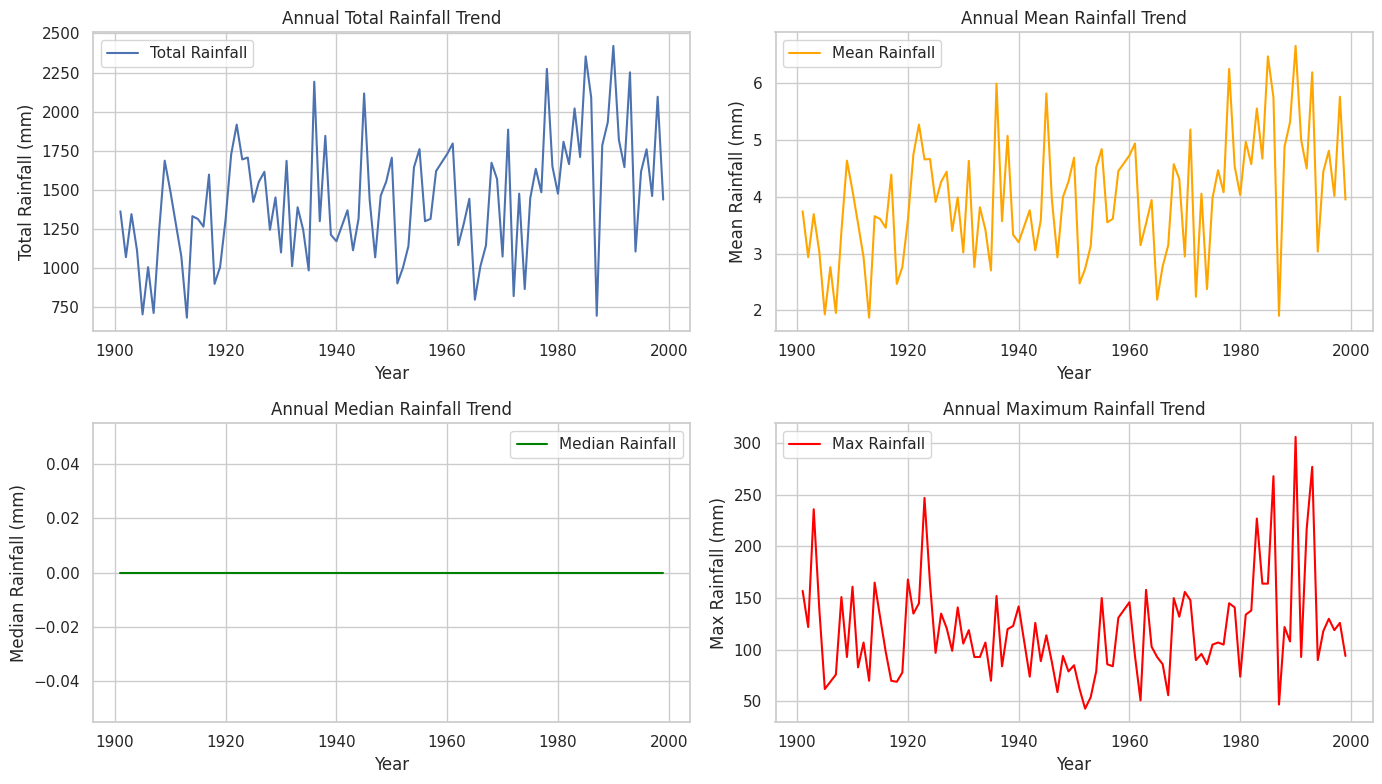

In [9]:
plt.figure(figsize=(14, 8))

# Total rainfall
plt.subplot(2, 2, 1)
plt.plot(annual_stats.index, annual_stats['Total'], label='Total Rainfall')
plt.xlabel('Year')
plt.ylabel('Total Rainfall (mm)')
plt.title('Annual Total Rainfall Trend')
plt.legend()

# Mean rainfall
plt.subplot(2, 2, 2)
plt.plot(annual_stats.index, annual_stats['Mean'], label='Mean Rainfall', color='orange')
plt.xlabel('Year')
plt.ylabel('Mean Rainfall (mm)')
plt.title('Annual Mean Rainfall Trend')
plt.legend()

# Median rainfall
plt.subplot(2, 2, 3)
plt.plot(annual_stats.index, annual_stats['Median'], label='Median Rainfall', color='green')
plt.xlabel('Year')
plt.ylabel('Median Rainfall (mm)')
plt.title('Annual Median Rainfall Trend')
plt.legend()

# Max rainfall
plt.subplot(2, 2, 4)
plt.plot(annual_stats.index, annual_stats['Max'], label='Max Rainfall', color='red')
plt.xlabel('Year')
plt.ylabel('Max Rainfall (mm)')
plt.title('Annual Maximum Rainfall Trend')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
for col in ['Total', 'Mean', 'Median', 'Max']:
    slope, intercept, r_value, p_value, std_err = stats.linregress(annual_stats.index, annual_stats[col])
    trend = "increasing" if slope > 0 else "decreasing"
    print(f"{col} Trend: Slope = {slope:.4f}, p-value = {p_value:.4f} ({trend} trend)")

Total Trend: Slope = 5.3592, p-value = 0.0001 (increasing trend)
Mean Trend: Slope = 0.0147, p-value = 0.0001 (increasing trend)
Median Trend: Slope = 0.0000, p-value = 1.0000 (decreasing trend)
Max Trend: Slope = 0.2496, p-value = 0.1554 (increasing trend)


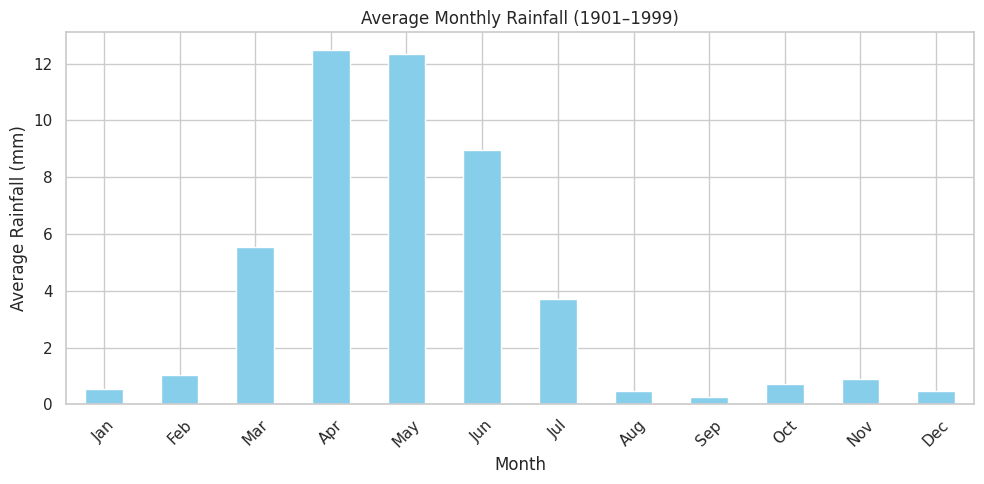

In [11]:
monthly_avg = df_long.groupby('Month')['Rainfall'].mean()

plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='bar', color='skyblue')

plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.title('Average Monthly Rainfall (1901–1999)')
plt.xticks(range(12), [calendar.month_abbr[i+1] for i in range(12)], rotation=45)

plt.tight_layout()
plt.show()

#### 6. 🧬 Distributional Insights
- **Box/Violin Plots**: Show rainfall distributions by year, month, season, and decade.  
- **Decadal Overlays**: Compare daily rainfall histograms/KDEs across decades.  
- **Categories**: Classify rainfall (e.g., light <2.5 mm, heavy >10 mm) and trend frequencies.  
- **CDFs**: Plot cumulative distribution functions by decade to quantify probability shifts.


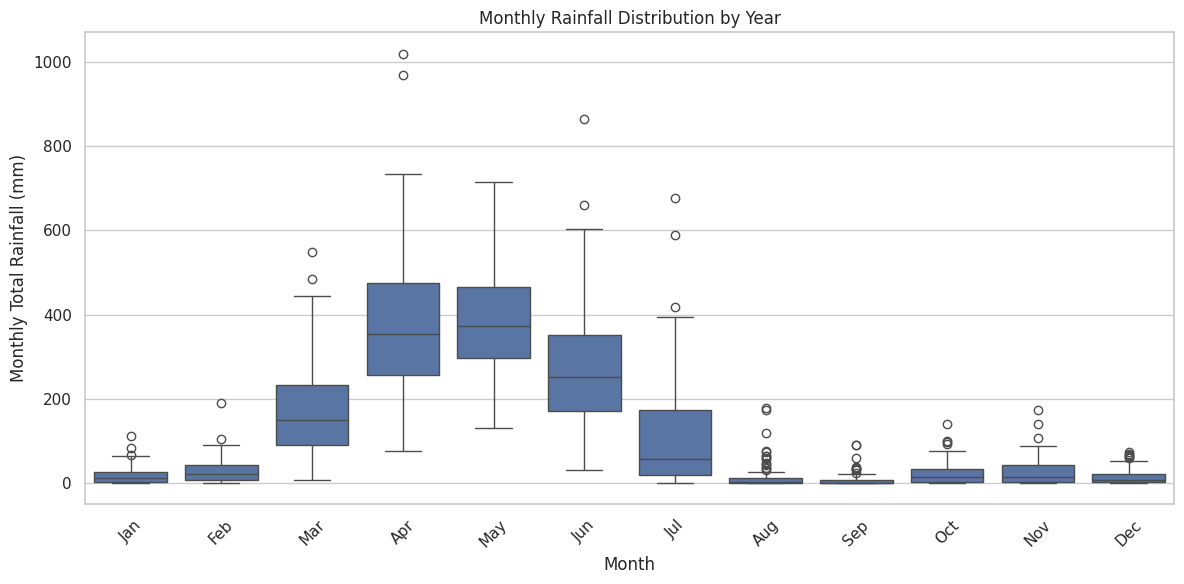

In [12]:
monthly_yearly = df_long.groupby(['Year', 'Month'])['Rainfall'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Rainfall', data=monthly_yearly)

plt.xlabel('Month')
plt.ylabel('Monthly Total Rainfall (mm)')
plt.title('Monthly Rainfall Distribution by Year')
plt.xticks(range(12), [calendar.month_abbr[i+1] for i in range(12)], rotation=45)

plt.tight_layout()
plt.show()



#### 4. 🗓️ Seasonal & Temporal Patterns
- **Seasons**: Define climatologically relevant seasons (e.g., Monsoon: Jun–Sep) or use data-driven clustering, then analyze seasonal trends.  
- **Monthly Patterns**: Examine monthly rainfall distributions and their evolution.  
- **Monsoon Timing**: Estimate annual onset/withdrawal (e.g., first/last day >5 mm) and trend over time.  
- **Spells**: Quantify wet (>0 mm) and dry (0 mm) spell durations and frequencies, assessing risk trends.


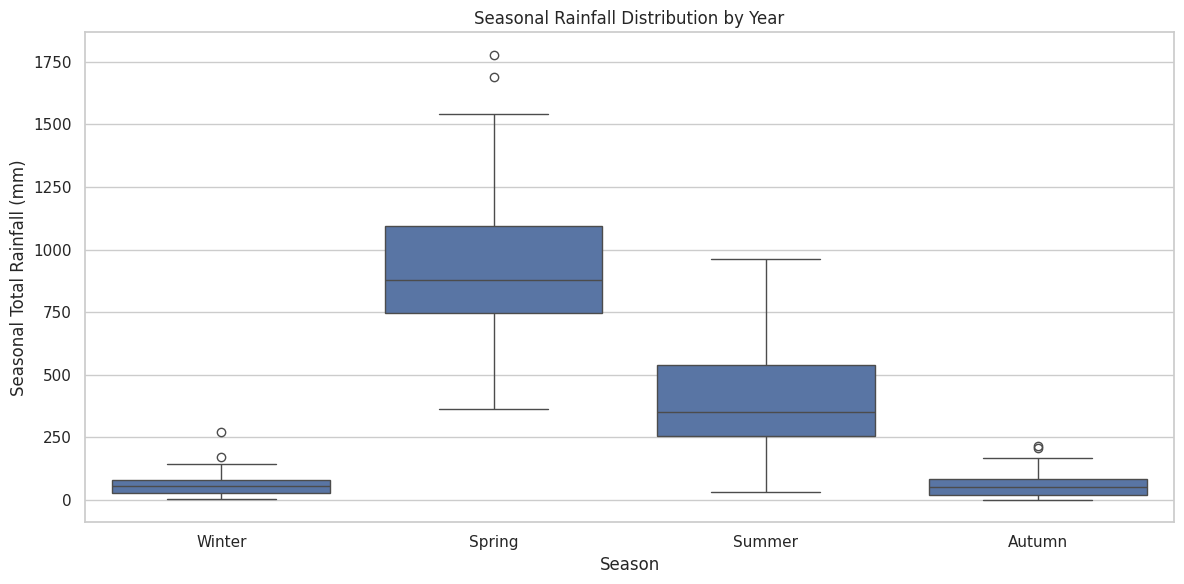

In [13]:
# Ensure you're using the correct DataFrame
df_melted = df_long  # if not already set

# Define seasons
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

# Map seasons
df_melted['Season'] = df_melted['Month'].map(season_map)

# Seasonal totals per year
seasonal_yearly = df_melted.groupby(['Year', 'Season'])['Rainfall'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Season', y='Rainfall', data=seasonal_yearly, order=['Winter', 'Spring', 'Summer', 'Autumn'])

plt.xlabel('Season')
plt.ylabel('Seasonal Total Rainfall (mm)')
plt.title('Seasonal Rainfall Distribution by Year')
plt.tight_layout()
plt.show()


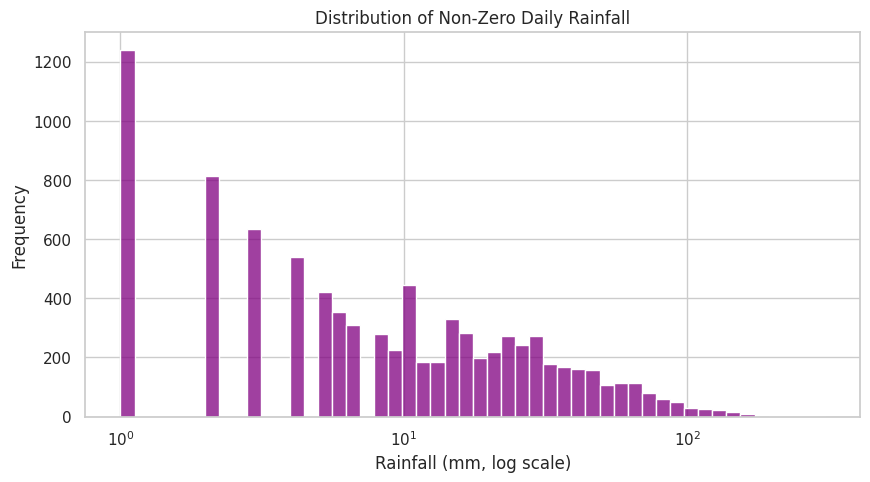

In [14]:
non_zero_rain = df_melted[df_melted['Rainfall'] > 0]['Rainfall']
plt.figure(figsize=(10, 5))
sns.histplot(non_zero_rain, bins=50, log_scale=True, color='purple')
plt.xlabel('Rainfall (mm, log scale)')
plt.ylabel('Frequency')
plt.title('Distribution of Non-Zero Daily Rainfall')
plt.show()

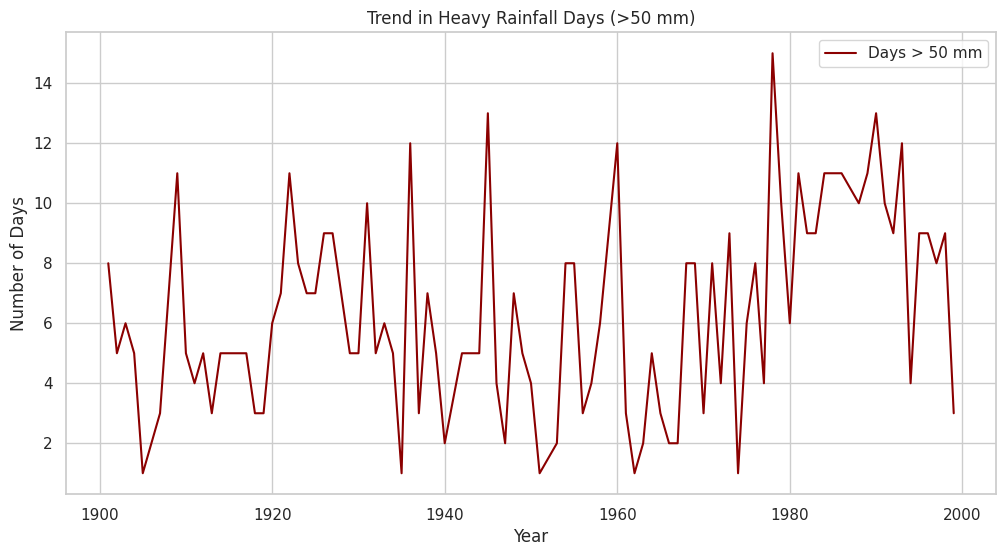

In [15]:
# Count days > 50 mm per year
heavy_rain = df_melted[df_melted['Rainfall'] > 50].groupby('Year').size()
plt.figure(figsize=(12, 6))
plt.plot(heavy_rain.index, heavy_rain.values, label='Days > 50 mm', color='darkred')
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.title('Trend in Heavy Rainfall Days (>50 mm)')
plt.legend()
plt.show()

#### 5. 🌡️ Heatmaps & Calendar Visualizations
- **Daily Heatmap**: Plot days (y-axis) vs. years (x-axis) with rainfall intensity as color to show patterns.  
- **Monthly Heatmap**: Aggregate to monthly totals for a heatmap of peak periods.  
- **Anomaly Heatmap**: Display daily anomalies (vs. 1901–1999 means) to highlight unusual years.

---

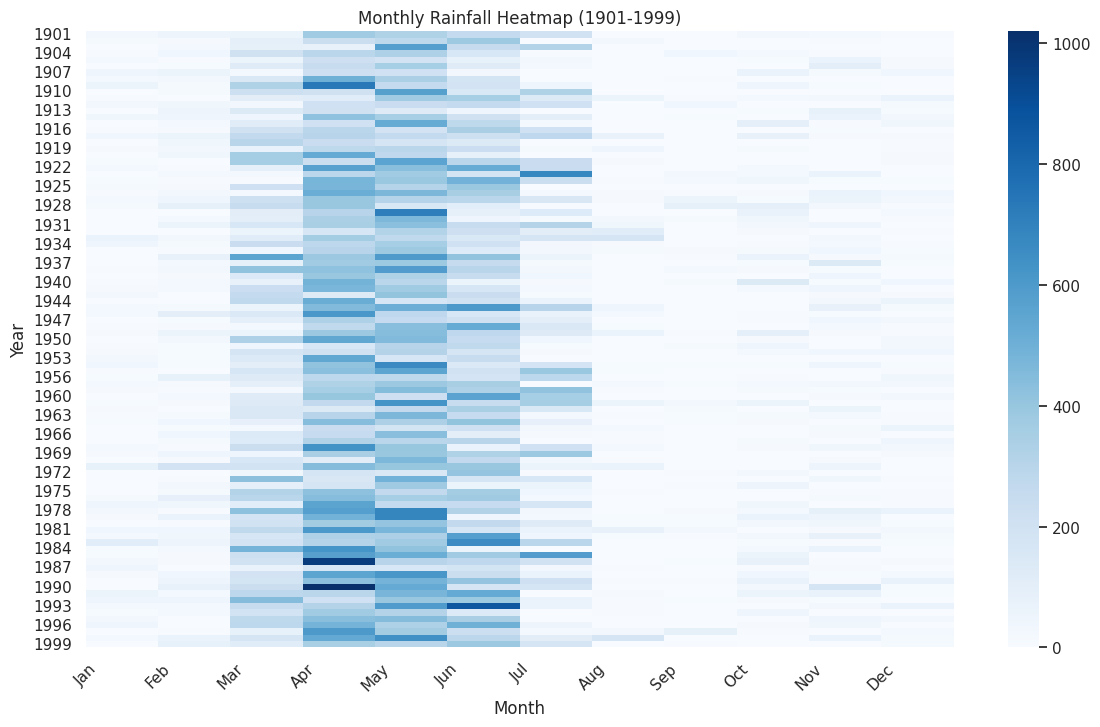

In [16]:
monthly_pivot = df_melted.groupby(['Year', 'Month'])['Rainfall'].sum().unstack()
plt.figure(figsize=(14, 8))
sns.heatmap(monthly_pivot, cmap='Blues', annot=False)
plt.xlabel('Month')
plt.ylabel('Year')
plt.title('Monthly Rainfall Heatmap (1901-1999)')
plt.xticks(range(12), [calendar.month_abbr[i+1] for i in range(12)], rotation=45)
plt.show()

---

#### 8. 📅 Year-over-Year and Historical Comparisons
- **Yearly Changes**: Plot percentage changes in annual rainfall.  
- **Wettest/Driest**: Rank top 5 wettest/driest years by total and max rainfall.  
- **Decadal Shifts**: Test differences across decades.  
- **Mid-Century**: Compare pre- and post-1950 patterns for climate change signals.

---

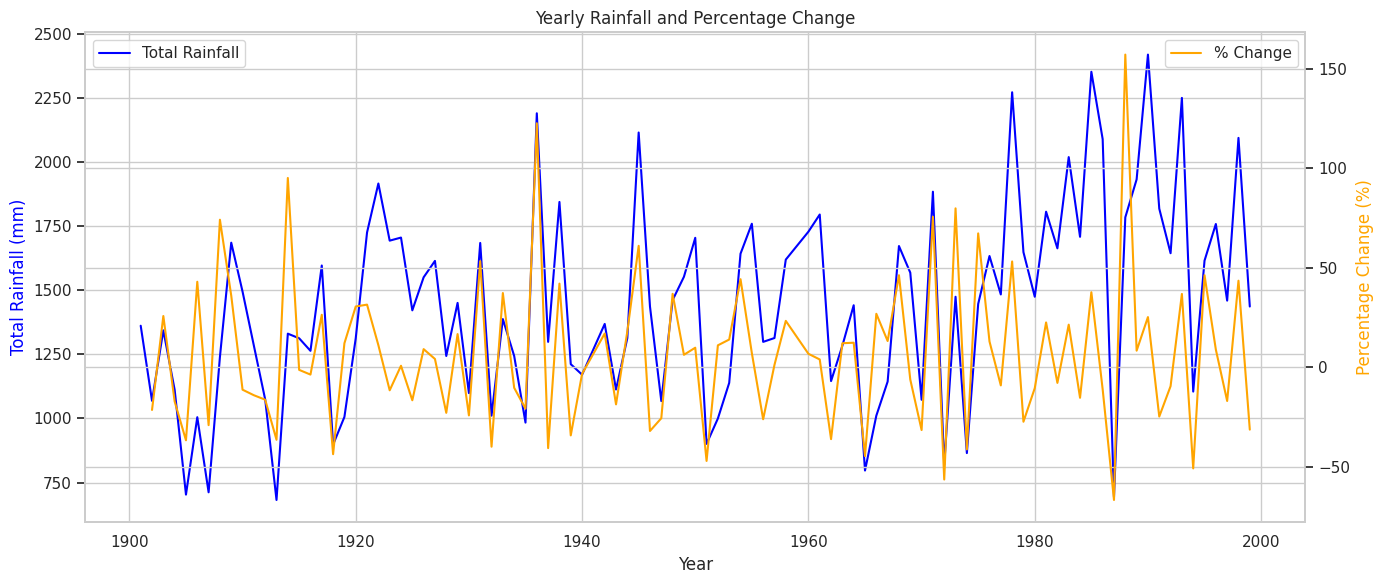

In [17]:
# Total yearly rainfall
annual_total = df_long.groupby('Year')['Rainfall'].sum().reset_index()

# Calculate year-over-year percentage change
annual_total['Pct_Change'] = annual_total['Rainfall'].pct_change() * 100

# Plot total and % change
fig, ax1 = plt.subplots(figsize=(14, 6))

# Total rainfall
sns.lineplot(data=annual_total, x='Year', y='Rainfall', ax=ax1, label='Total Rainfall', color='blue')
ax1.set_ylabel('Total Rainfall (mm)', color='blue')

# % Change
ax2 = ax1.twinx()
sns.lineplot(data=annual_total, x='Year', y='Pct_Change', ax=ax2, label='% Change', color='orange')
ax2.set_ylabel('Percentage Change (%)', color='orange')

plt.title('Yearly Rainfall and Percentage Change')
plt.tight_layout()
plt.show()


In [18]:
# Wettest
top_wettest = annual_total.nlargest(5, 'Rainfall')
# Driest
top_driest = annual_total.nsmallest(5, 'Rainfall')

print("🌧️ Top 5 Wettest Years:\n", top_wettest)
print("\n🔥 Top 5 Driest Years:\n", top_driest)


🌧️ Top 5 Wettest Years:
     Year  Rainfall  Pct_Change
87  1990    2420.0   25.193999
82  1985    2353.0   37.682855
75  1978    2273.0   53.167116
90  1993    2251.0   36.838906
35  1936    2191.0  122.662602

🔥 Top 5 Driest Years:
     Year  Rainfall  Pct_Change
12  1913     682.0  -36.499069
84  1987     694.0  -66.794258
4   1905     703.0  -36.780576
6   1907     712.0  -29.154229
62  1965     797.0  -44.729542


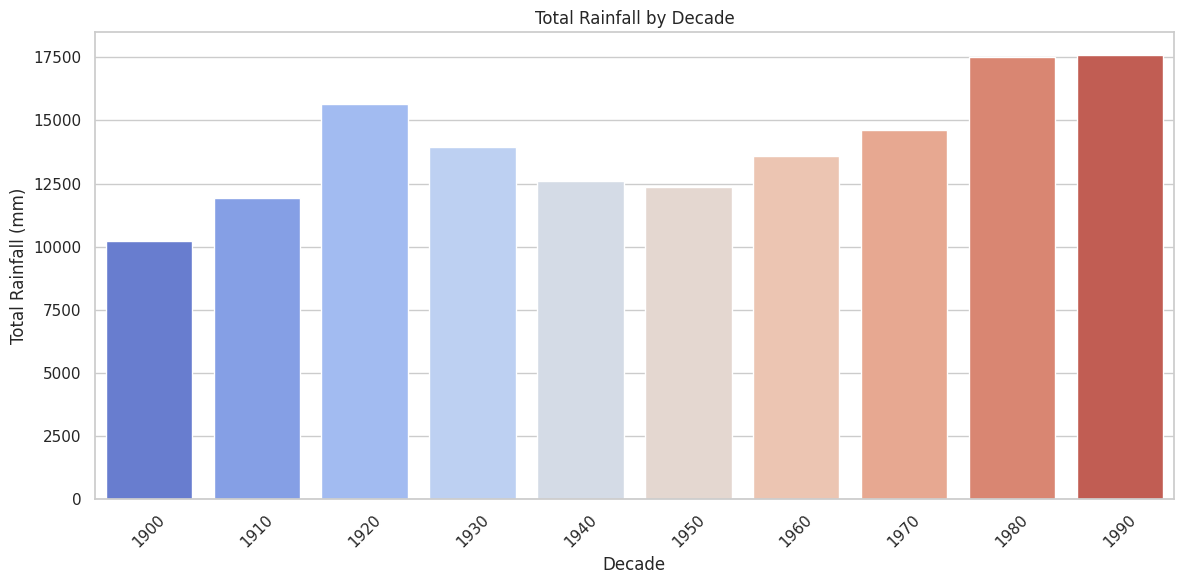

In [19]:
# Create 'Decade' column
df_long['Decade'] = (df_long['Year'] // 10) * 10

# Group by decade
decadal_rainfall = df_long.groupby('Decade')['Rainfall'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Decade', y='Rainfall', data=decadal_rainfall, palette='coolwarm')
plt.title('Total Rainfall by Decade')
plt.ylabel('Total Rainfall (mm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

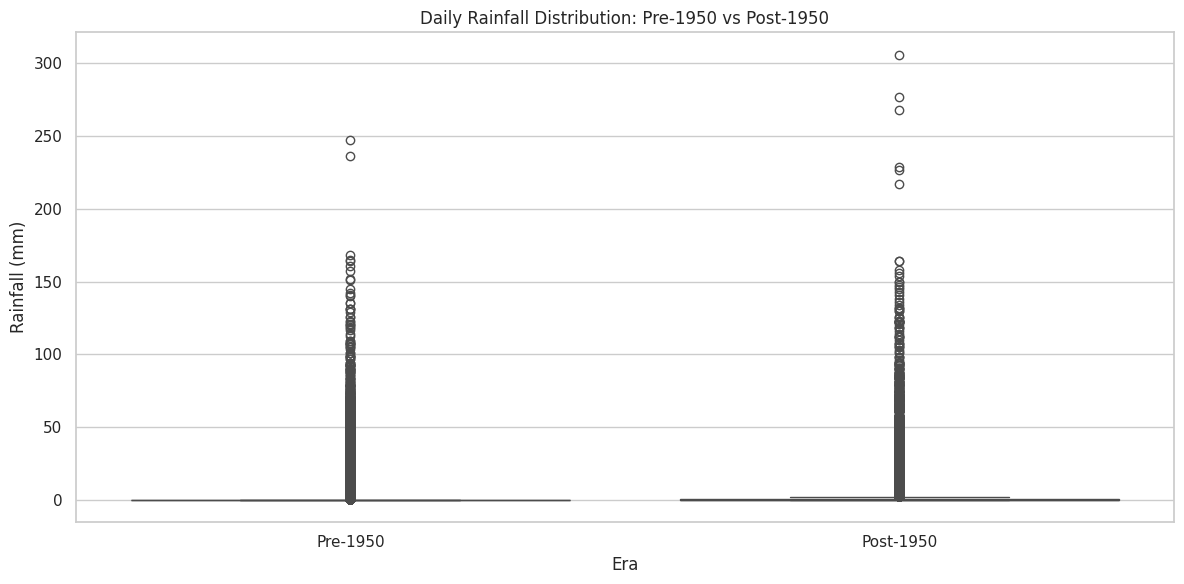

In [20]:
# Label periods
df_long['Era'] = df_long['Year'].apply(lambda y: 'Pre-1950' if y < 1950 else 'Post-1950')

# Compare distributions
plt.figure(figsize=(12, 6))
sns.boxplot(x='Era', y='Rainfall', data=df_long)
plt.title('Daily Rainfall Distribution: Pre-1950 vs Post-1950')
plt.ylabel('Rainfall (mm)')
plt.tight_layout()
plt.show()

In [21]:
from scipy.stats import ttest_ind

pre = df_long[df_long['Era'] == 'Pre-1950']['Rainfall']
post = df_long[df_long['Era'] == 'Post-1950']['Rainfall']

t_stat, p_val = ttest_ind(pre, post, equal_var=False)
print(f"t-statistic = {t_stat:.2f}, p-value = {p_val:.4f}")

t-statistic = nan, p-value = nan


In [22]:
### Section 3: Trend Analysis

# Annual total rainfall
annual_total = df_long.groupby('Year')['Rainfall'].sum()
slope, intercept, r_value, p_value, std_err = linregress(annual_total.index, annual_total.values)
print(f"\nAnnual Rainfall Trend - Slope: {slope:.4f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Significant trend detected in annual rainfall.")

# Extreme events (99th percentile)
p99 = df_long['Rainfall'].quantile(0.99)
extreme_days = df_long[df_long['Rainfall'] > p99].groupby('Year').size()


Annual Rainfall Trend - Slope: 5.3592, P-value: 0.0001
Significant trend detected in annual rainfall.


In [24]:
### Section 4: Seasonal and Temporal Patterns

# Seasonal totals
seasonal_total = df_long.groupby(['Year', 'Season'])['Rainfall'].sum().unstack()

# Monthly mean rainfall
monthly_mean = df_long.groupby('Month')['Rainfall'].mean()

print(f"{seasonal_total}\n{monthly_mean}")

Season  Autumn  Spring  Summer  Winter
Year                                  
1901      53.0   761.0   459.0    89.0
1902       4.0   612.0   420.0    33.0
1903       3.0   745.0   570.0    26.0
1904      72.0   827.0   170.0    43.0
1905      78.0   470.0   110.0    45.0
...        ...     ...     ...     ...
1995      48.0  1160.0   347.0    61.0
1996      56.0  1100.0   554.0    49.0
1997      95.0  1054.0   284.0    27.0
1998      67.0  1347.0   574.0   107.0
1999       8.0   767.0   562.0   100.0

[97 rows x 4 columns]
Month
1      0.544064
2      1.031752
3      5.530429
4     12.477320
5     12.345527
6      8.968729
7      3.714998
8      0.471234
9      0.241924
10     0.725631
11     0.887285
12     0.486864
Name: Rainfall, dtype: float64


In [28]:
### Section 5: Visualizations
!pip install -U nbformat


# 1. Annual Total Rainfall (Interactive Plot)
fig = px.line(annual_total.reset_index(), x='Year', y='Rainfall', 
              title='Annual Total Rainfall (1901-1999)', 
              labels={'Rainfall': 'Total Rainfall (mm)'})
fig.update_layout(template='plotly_white')
fig.show()

# 2. Seasonal Trends
plt.figure(figsize=(12, 6))
seasonal_total.plot(kind='line', ax=plt.gca())
plt.title('Seasonal Total Rainfall Over Time')
plt.ylabel('Total Rainfall (mm)')
plt.legend(title='Season')
plt.show()

# 3. Monthly Rainfall Pattern
plt.figure(figsize=(10, 5))
monthly_mean.plot(kind='bar')
plt.title('Average Monthly Rainfall')
plt.xlabel('Month')
plt.ylabel('Mean Rainfall (mm)')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

# 4. Boxplot by Decade
annual_total_df = annual_total.reset_index()
annual_total_df['Decade'] = (annual_total_df['Year'] // 10) * 10
plt.figure(figsize=(12, 6))
sns.boxplot(x='Decade', y='Rainfall', data=annual_total_df)
plt.title('Annual Total Rainfall by Decade')
plt.ylabel('Total Rainfall (mm)')
plt.show()

# 5. Heatmap of Rainfall Anomalies
mean_per_day = df_long.groupby('Days')['Rainfall'].mean()
df_long['Anomaly'] = df_long['Rainfall'] - df_long['Days'].map(mean_per_day)
anomaly_pivot = df_long.pivot_table(index='Days', columns='Year', values='Anomaly')
plt.figure(figsize=(14, 8))
sns.heatmap(anomaly_pivot, cmap='RdBu_r', center=0)
plt.title('Daily Rainfall Anomalies (1901-1999)')
plt.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

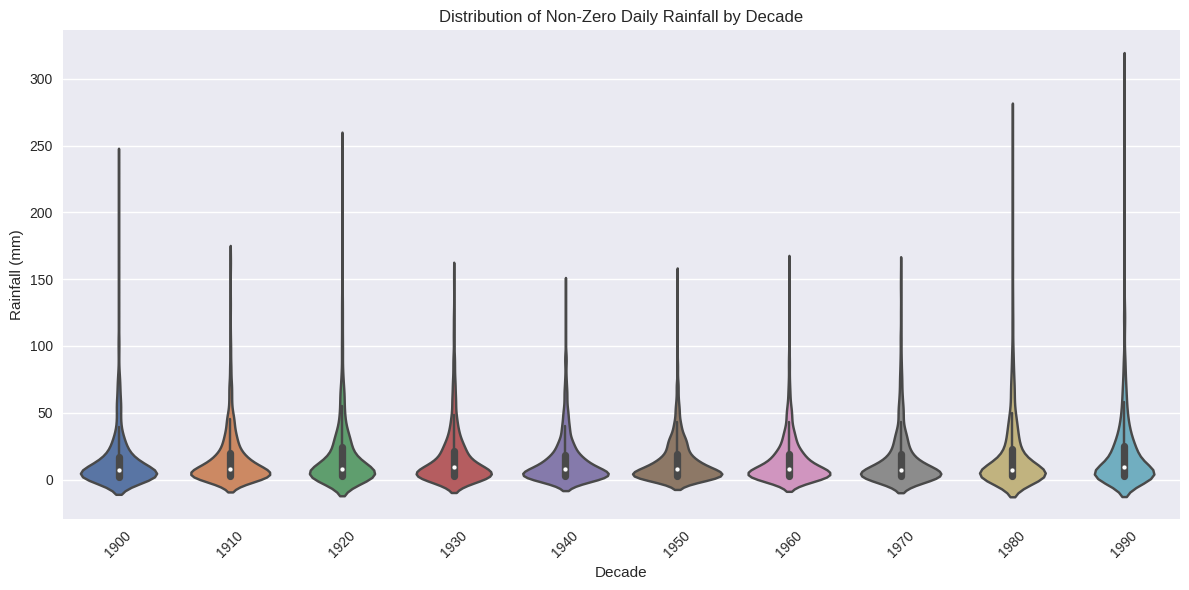

In [23]:
# Make sure 'df_long' has a 'Decade' column
df_long['Decade'] = (df_long['Year'] // 10) * 10

# Plot non-zero rainfall distribution by decade
plt.figure(figsize=(12, 6))
sns.violinplot(x='Decade', y='Rainfall', data=df_long[df_long['Rainfall'] > 0])
plt.title('Distribution of Non-Zero Daily Rainfall by Decade')
plt.ylabel('Rainfall (mm)')
plt.xlabel('Decade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

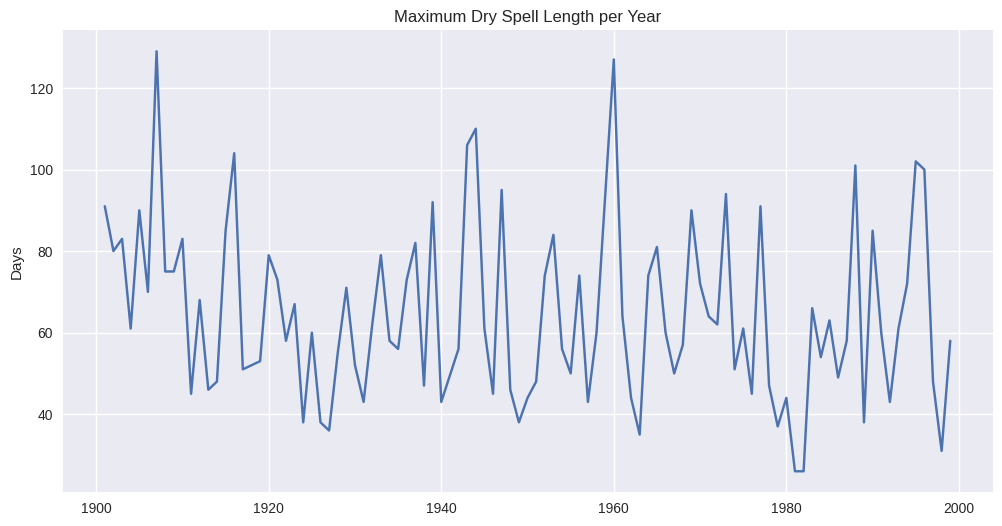

Processed data saved to 'rainfall_data_processed.csv'.


In [24]:
### Section 7: Additional Insights

# Wet and Dry Spells
df_long['Dry'] = (df_long['Rainfall'] == 0).astype(int)
max_dry_spells = []
for year in df_long['Year'].unique():
    year_data = df_long[df_long['Year'] == year]
    dry_runs = year_data['Dry']
    from itertools import groupby
    dry_lengths = [sum(1 for _ in group) for key, group in groupby(dry_runs) if key]
    max_dry = max(dry_lengths) if dry_lengths else 0
    max_dry_spells.append(max_dry)
max_dry_spells_df = pd.DataFrame({'Year': df_long['Year'].unique(), 'MaxDrySpell': max_dry_spells})
plt.figure(figsize=(12, 6))
plt.plot(max_dry_spells_df['Year'], max_dry_spells_df['MaxDrySpell'])
plt.title('Maximum Dry Spell Length per Year')
plt.ylabel('Days')
plt.show()

# Save processed data
df_long.to_csv('rainfall_data_processed.csv')
print("Processed data saved to 'rainfall_data_processed.csv'.")

#### 11. 📊 Advanced Visualization Summary
- **Interactive Line**: Annual rainfall with trends (Plotly/Altair).  
- **Histogram/KDE**: Decadal rainfall distributions.  
- **Heatmap**: Daily rainfall across years.  
- **Bar Plots**: Seasonal averages with error bars.  
- **Box/Violin**: Monthly/seasonal distributions.  
- **Decomposition**: Trend/seasonality/residuals.  
- **LOWESS Scatter**: Rainfall vs. day by decade.  
- **Timeline**: Mark extreme events.  
- **Calendar Heatmap**: Daily patterns for key years.

---

#### 7. 🧪 Anomaly & Extreme Event Analysis
- **Annual Anomalies**: Calculate deviations from the long-term mean, flagging significant years (e.g., Z-score >2).  
- **Extremes**: Model extreme events (>100 mm) with POT or GEV for frequency and return periods.  
- **Rolling Stats**: Use 30-day rolling means/std to detect intra-year anomalies.  
- **Visualization**: Annotate plots with extreme events.



#### 9. 📉 Time-Series Decomposition & Cyclical Analysis
- **STL Decomposition**: Separate trend, seasonality, and residuals.  
- **Cycles**: Use spectral analysis to detect multi-year patterns.  
- **Autocorrelation**: Analyze ACF/PACF for seasonality.  
- **Spell Trends**: Track wet/dry spell duration changes.

---

#### 10. 🌍 Domain-Specific Analysis
- **Intensity**: Trend high-intensity days (>50 mm).  
- **Climate Links**: Explore correlations with climate indices (if data available).  
- **Global Context**: Compare to 20th-century rainfall trends.  
- **Quality**: Assess biases from historical measurement changes.

---



#### 12. 🧠 Insights & Interpretation
- **Monsoon**: Assess changes in timing and intensity.  
- **Extremes**: Evaluate trends in heavy rainfall/dry spells.  
- **Shifts**: Identify long-term climatic patterns.  
- **Variability**: Comment on consistency.  
- **Conclusions**: Offer 3–5 actionable insights.

---

In [25]:
df_melted.head()
df_melted.describe

<bound method NDFrame.describe of        Days  Year  Rainfall  is_leap       Date  Month  Season  Decade  \
0         1  1901      24.0    False 1901-01-01      1  Winter    1900   
1         2  1901       0.0    False 1901-01-02      1  Winter    1900   
2         3  1901       0.0    False 1901-01-03      1  Winter    1900   
3         4  1901       0.0    False 1901-01-04      1  Winter    1900   
4         5  1901       0.0    False 1901-01-05      1  Winter    1900   
...     ...   ...       ...      ...        ...    ...     ...     ...   
35592   361  1999       0.0    False 1999-12-27     12  Winter    1990   
35593   362  1999       0.0    False 1999-12-28     12  Winter    1990   
35594   363  1999       0.0    False 1999-12-29     12  Winter    1990   
35595   364  1999       0.0    False 1999-12-30     12  Winter    1990   
35596   365  1999       0.0    False 1999-12-31     12  Winter    1990   

             Era    Anomaly  Dry  
0       Pre-1950  22.618557    0  
1      

In [26]:
import folium
import pandas as pd

# Load your dataset
# Replace this with your actual file path or DataFrame
df = df_melted  # Use your actual data file

# Static location
latitude = 28.75
longitude = 80.0

# Create a map
m = folium.Map(location=[latitude, longitude], zoom_start=6)

# Loop through the dataframe and plot
for idx, row in df.iterrows():
    rainfall = row['Rainfall']
    date = row['Date']
    
    # Radius and color logic
    radius = max(2, min(rainfall / 2, 15))
    
    if rainfall == 0:
        color = "gray"
    elif rainfall < 10:
        color = "lightblue"
    elif rainfall < 50:
        color = "blue"
    else:
        color = "darkblue"

    folium.CircleMarker(
        location=[latitude, longitude],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=f"{date}: {rainfall} mm"
    ).add_to(m)

# Save and show the map
m.save("rainfall_map.html")

In [27]:
import pandas as pd
import folium
import plotly.express as px
import plotly.io as pio

df = df_melted
# =============================================================================
# 2. Create the Visualizations (Using Plotly)
# =============================================================================
# 2.1 Annual Total Rainfall (Interactive Line Plot)
annual_total = df.groupby('Year')['Rainfall'].sum().reset_index()
fig_annual = px.line(
    annual_total, 
    x='Year', 
    y='Rainfall',
    title='Annual Total Rainfall',
    labels={'Rainfall': 'Total Rainfall (mm)'}
)
# Convert the Plotly figure to an HTML string (for embedding)
fig_annual_html = pio.to_html(fig_annual, include_plotlyjs='cdn', full_html=False)

# 2.2 Seasonal Trends
seasonal_total = df.groupby(['Year','Season'])['Rainfall'].sum().reset_index()
fig_season = px.line(
    seasonal_total, 
    x='Year', 
    y='Rainfall', 
    color='Season',
    title='Seasonal Total Rainfall',
    labels={'Rainfall': 'Total Rainfall (mm)'}
)
fig_season_html = pio.to_html(fig_season, include_plotlyjs='cdn', full_html=False)

# 2.3 Monthly Rainfall Pattern (Bar Chart for Mean Rainfall)
monthly_mean = df.groupby('Month')['Rainfall'].mean().reset_index()
fig_monthly = px.bar(
    monthly_mean,
    x='Month', 
    y='Rainfall',
    title='Average Monthly Rainfall',
    labels={'Rainfall':'Mean Rainfall (mm)', 'Month':'Month'}
)
fig_monthly_html = pio.to_html(fig_monthly, include_plotlyjs='cdn', full_html=False)

# =============================================================================
# 3. Create a Folium Map and Embed the Visualizations as Popups
# =============================================================================
# We'll center the map near (28.75, 80.0)
latitude = 28.75
longitude = 80.0
m = folium.Map(location=[latitude, longitude], zoom_start=6)

# Helper function to add a marker with an embedded Plotly chart popup
def add_plot_marker(map_obj, html_string, location, popup_title):
    # Adjust popup size (width/height) as needed
    iframe = folium.IFrame(html=html_string, width=500, height=400)
    popup = folium.Popup(iframe, max_width=500)
    folium.Marker(location=location, popup=popup, tooltip=popup_title).add_to(map_obj)

# Place markers around the central location (to avoid overlap)
add_plot_marker(m, fig_annual_html, [latitude + 0.2, longitude - 0.2], "Annual Total Rainfall")
add_plot_marker(m, fig_season_html, [latitude + 0.2, longitude + 0.2], "Seasonal Trends")
add_plot_marker(m, fig_monthly_html, [latitude - 0.2, longitude], "Monthly Rainfall Pattern")

# Save or display the map
m.save("rainfall_trends_map.html")



In [29]:
import pandas as pd
import plotly.express as px

# Example DataFrame simulating annual rainfall data
# Replace this synthetic data with your actual dataset
annual_data = pd.DataFrame({
    'Year': list(range(1901, 2000)),  # 1901 to 1999
    'Rainfall': [24.0 + i % 10 * 2 for i in range(99)]  # synthetic rainfall values
})

# Add coordinate columns (same for every row)
annual_data['lat'] = 28.75
annual_data['lon'] = 80.0

# Create animated scatter_mapbox plot (animation_frame set to 'Year')
fig_annual = px.scatter_mapbox(
    annual_data,
    lat='lat',
    lon='lon',
    size='Rainfall',           # Marker size reflects rainfall
    color='Rainfall',          # Marker color reflects rainfall intensity
    animation_frame='Year',    # Each year becomes a frame in the animation
    color_continuous_scale="YlOrRd",
    size_max=50,               # Adjust maximum marker size as needed
    zoom=7,
    center={'lat': 28.75, 'lon': 80.0},
    mapbox_style="carto-positron",
    title="Annual Rainfall at (28.75, 80.0)"
)

fig_annual.update_layout(margin={"r":0,"t":30,"l":0,"b":0})
fig_annual.show()

# Save if needed:
# fig_annual.write_html("annual_rainfall_animation.html")


In [30]:
# Example DataFrame simulating seasonal rainfall data at the same location
seasonal_data = pd.DataFrame({
    'Year': [1901] * 4,
    'Season': ['Winter', 'Pre-Monsoon', 'Monsoon', 'Post-Monsoon'],
    'Rainfall': [15, 10, 50, 20]
})
seasonal_data['lat'] = 28.75
seasonal_data['lon'] = 80.0

# Animate by season
fig_season = px.scatter_mapbox(
    seasonal_data,
    lat='lat',
    lon='lon',
    size='Rainfall',
    color='Rainfall',
    animation_frame='Season',
    color_continuous_scale="Blues",
    size_max=50,
    zoom=7,
    center={'lat': 28.75, 'lon': 80.0},
    mapbox_style="carto-positron",
    title="Seasonal Rainfall at (28.75, 80.0)"
)

fig_season.update_layout(margin={"r":0,"t":30,"l":0,"b":0})
fig_season.show()

# Save if needed:
# fig_season.write_html("seasonal_rainfall_animation.html")


In [31]:
# Example DataFrame simulating monthly rainfall (use your actual monthly data)
monthly_data = pd.DataFrame({
    'Year': [1901]*12,
    'Month': list(range(1, 13)),
    'Rainfall': [5, 7, 20, 30, 45, 60, 55, 40, 25, 15, 10, 8]
})
monthly_data['TimeLabel'] = monthly_data['Year'].astype(str) + "-" + monthly_data['Month'].astype(str)
monthly_data['lat'] = 28.75
monthly_data['lon'] = 80.0

fig_month = px.scatter_mapbox(
    monthly_data,
    lat='lat',
    lon='lon',
    size='Rainfall',
    color='Rainfall',
    animation_frame='TimeLabel',  # Each month is an animation frame
    color_continuous_scale="YlGnBu",
    size_max=50,
    zoom=7,
    center={'lat': 28.75, 'lon': 80.0},
    mapbox_style="carto-positron",
    title="Monthly Rainfall at (28.75, 80.0)"
)

fig_month.update_layout(margin={"r":0,"t":30,"l":0,"b":0})
fig_month.show()

# Save if needed:
# fig_month.write_html("monthly_rainfall_animation.html")


In [32]:
# Example DataFrame simulating annual rainfall data from 1901 to 1999
annual_data = pd.DataFrame({
    'Year': list(range(1901, 2000)),
    'Rainfall': [24.0 + i % 10 * 2 for i in range(99)]
})
# Create a Decade column
annual_data['Decade'] = (annual_data['Year'] // 10) * 10
# Group by Decade (for instance, by taking the mean rainfall in that decade)
decade_data = annual_data.groupby('Decade').mean().reset_index()

# Add coordinates
decade_data['lat'] = 28.75
decade_data['lon'] = 80.0

fig_decade = px.scatter_mapbox(
    decade_data,
    lat='lat',
    lon='lon',
    size='Rainfall',
    color='Rainfall',
    animation_frame='Decade',
    color_continuous_scale="RdPu",
    size_max=50,
    zoom=7,
    center={'lat': 28.75, 'lon': 80.0},
    mapbox_style="carto-positron",
    title="Decadal Rainfall at (28.75, 80.0)"
)

fig_decade.update_layout(margin={"r":0,"t":30,"l":0,"b":0})
fig_decade.show()

# Save if needed:
# fig_decade.write_html("decadal_rainfall_animation.html")


In [34]:
import pandas as pd
import plotly.express as px

# Example: Create synthetic annual rainfall data from 1901 to 1999
annual_data = pd.DataFrame({
    'Year': list(range(1901, 2000)),
    'Rainfall': [24.0 + i % 10 * 2 for i in range(99)]  # Synthetic rainfall values
})

# Calculate anomaly based on a baseline of 30 (change as needed)
annual_data['Baseline'] = 30
annual_data['Anomaly'] = annual_data['Rainfall'] - annual_data['Baseline']

# Create a new column for marker size that is non-negative (absolute value of anomaly)
annual_data['MarkerSize'] = annual_data['Anomaly'].abs()

# Add the fixed coordinates for your location
annual_data['lat'] = 28.75
annual_data['lon'] = 80.0

# Create an animated scatter_mapbox plot
fig_anomaly = px.scatter_mapbox(
    annual_data,
    lat='lat',                      # Latitude column
    lon='lon',                      # Longitude column
    size='MarkerSize',              # Use non-negative marker size
    color='Anomaly',                # Color shows the actual anomaly (can be negative)
    animation_frame='Year',         # Animate by year
    color_continuous_scale="RdBu",  # Diverging color scale
    size_max=50,                    # Maximum marker size (adjust as needed)
    zoom=7,
    center={'lat': 28.75, 'lon': 80.0},
    mapbox_style="carto-positron",
    title="Rainfall Anomalies Over Time at (28.75, 80.0)"
)

fig_anomaly.update_layout(margin={"r":0, "t":30, "l":0, "b":0})
fig_anomaly.show()

# Save the animation if needed:
# fig_anomaly.write_html("anomaly_rainfall_animation.html")


In [ ]:
fig_annual_map.write_html("annual_rainfall_animation.html")
fig_season_map.write_html("seasonal_rainfall_animation.html")
fig_month_map.write_html("monthly_rainfall_animation.html")
fig_decade_map.write_html("decadal_rainfall_animation.html")
fig_anomaly_map.write_html("anomaly_rainfall_animation.html")


In [3]:
import os
import re
import calendar
import pandas as pd
import plotly.express as px
import plotly.io as pio
import folium

# -----------------------------------------------
# 1. SETTINGS & DATA PATHS
# -----------------------------------------------
data_dir = '/kaggle/input/rainfall-data'
csv_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.csv')]
rainfall_columns = [str(year) for year in range(1901, 2000) if year not in [1941, 1959]]

# -----------------------------------------------
# 2. READ AND PROCESS ALL CSV FILES
# -----------------------------------------------
data_list = []
for file in csv_files:
    match = re.search(r'fid_(\d+)_data', file)
    if not match:
        continue
    fid = int(match.group(1))
    df = pd.read_csv(file)
    df['Days'] = range(1, len(df) + 1)
    
    # Replace negative values with 0
    if (df[rainfall_columns] < 0).any().any():
        df[rainfall_columns] = df[rainfall_columns].clip(lower=0)
    
    # Ensure numeric conversion
    for col in rainfall_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Reshape data from wide to long
    df_long = pd.melt(df,
                      id_vars=['Days'],
                      value_vars=rainfall_columns,
                      var_name='Year',
                      value_name='Rainfall')
    df_long['Year'] = df_long['Year'].astype(int)
    df_long['FID'] = fid
    
    # Mark leap years and filter valid days
    df_long['is_leap'] = df_long['Year'].apply(calendar.isleap)
    df_long = df_long[
        (df_long['is_leap'] & (df_long['Days'] <= 366)) |
        (~df_long['is_leap'] & (df_long['Days'] <= 365))
    ]
    
    # Create Date and Month columns
    df_long['Date'] = pd.to_datetime(df_long['Year'].astype(str) + '-' + df_long['Days'].astype(str),
                                     format='%Y-%j', errors='coerce')
    df_long.sort_values('Date', inplace=True)
    df_long['Month'] = df_long['Date'].dt.month
    
    data_list.append(df_long)

df_all = pd.concat(data_list, ignore_index=True)
print("Combined data shape:", df_all.shape)
print(df_all.head())

# -----------------------------------------------
# 3. MERGE WITH COORDINATE INFORMATION
# -----------------------------------------------
# Create coordinate DataFrame (FID, lat, lon)
coord_data = [
    [0,   28.75, 80],
    [1,   29.0, 79.25],
    [2,   29.0, 79.5],
    [3,   29.0, 79.75],
    [4,   29.0, 80],
    [5,   29.25, 79],
    [6,   29.25, 79.25],
    [7,   29.25, 79.5],
    [8,   29.25, 79.75],
    [9,   29.25, 80],
    [10,  29.25, 80.25],
    [11,  29.5, 78.75],
    [12,  29.5, 79],
    [13,  29.5, 79.25],
    [14,  29.5, 79.5],
    [15,  29.5, 79.75],
    [16,  29.5, 80],
    [17,  29.5, 80.25],
    [18,  29.75, 78],
    [19,  29.75, 78.25],
    [20,  29.75, 78.5],
    [21,  29.75, 78.75],
    [22,  29.75, 79],
    [23,  29.75, 79.25],
    [24,  29.75, 79.5],
    [25,  29.75, 79.75],
    [26,  29.75, 80],
    [27,  29.75, 80.25],
    [28,  30.0, 77.75],
    [29,  30.0, 78],
    [30,  30.0, 78.25],
    [31,  30.0, 78.5],
    [32,  30.0, 78.75],
    [33,  30.0, 79],
    [34,  30.0, 79.25],
    [35,  30.0, 79.5],
    [36,  30.0, 79.75],
    [37,  30.0, 80],
    [38,  30.0, 80.25],
    [39,  30.0, 80.5],
    [40,  30.25, 78],
    [41,  30.25, 78.25],
    [42,  30.25, 78.5],
    [43,  30.25, 78.75],
    [44,  30.25, 79],
    [45,  30.25, 79.25],
    [46,  30.25, 79.5],
    [47,  30.25, 79.75],
    [48,  30.25, 80],
    [49,  30.25, 80.25],
    [50,  30.25, 80.5],
    [51,  30.25, 80.75],
    [52,  30.25, 81],
    [53,  30.5, 78],
    [54,  30.5, 78.25],
    [55,  30.5, 78.5],
    [56,  30.5, 78.75],
    [57,  30.5, 79],
    [58,  30.5, 79.25],
    [59,  30.5, 79.5],
    [60,  30.5, 79.75],
    [61,  30.5, 80],
    [62,  30.5, 80.25],
    [63,  30.75, 77.75],
    [64,  30.75, 78],
    [65,  30.75, 78.25],
    [66,  30.75, 78.5],
    [67,  30.75, 78.75],
    [68,  30.75, 79],
    [69,  30.75, 79.25],
    [70,  30.75, 79.5],
    [71,  30.75, 79.75],
    [72,  30.75, 80],
    [73,  31.0, 78],
    [74,  31.0, 78.25],
    [75,  31.0, 78.5],
    [76,  31.0, 78.75],
    [77,  31.0, 79],
    [78,  31.0, 79.25],
    [79,  31.0, 79.5],
    [80,  31.0, 79.75],
    [81,  31.25, 78.25],
    [82,  31.25, 79]
]
df_coords = pd.DataFrame(coord_data, columns=['FID', 'lat', 'lon'])
# Merge coordinates into the daily data
df_all = df_all.merge(df_coords, on='FID', how='left')
print("Data with coordinates (sample):")
print(df_all[['FID', 'lat', 'lon']].drop_duplicates().head())

# -----------------------------------------------
# 4. AGGREGATE THE RAINFALL DATA FOR VISUALIZATIONS
# -----------------------------------------------
# (a) Annual Total Rainfall by Station
annual_total = df_all.groupby(['FID', 'Year'], as_index=False)['Rainfall'].sum()
annual_total['Baseline'] = 30
annual_total['Anomaly'] = annual_total['Rainfall'] - annual_total['Baseline']
annual_total['MarkerSize'] = annual_total['Anomaly'].abs()
annual_total['Decade'] = (annual_total['Year'] // 10) * 10
# Merge coordinate info back into annual_total:
annual_total = annual_total.merge(df_coords, on='FID', how='left')

# (b) Decadal Average Rainfall
decade_avg = annual_total.groupby(['FID', 'Decade'], as_index=False)['Rainfall'].mean()
decade_avg = decade_avg.merge(df_coords, on='FID', how='left')

# (c) Monthly Average Rainfall for Each Station
monthly_mean = df_all.groupby(['FID', 'Year', 'Month'], as_index=False)['Rainfall'].mean()
monthly_mean['TimeLabel'] = monthly_mean['Year'].astype(str) + "-" + monthly_mean['Month'].astype(str)
# (Coordinates can be merged later if needed; for station-specific plots we add them)

# (d) Seasonal Total Rainfall
def assign_season(month):
    if month in [1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Pre-Monsoon'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'
df_all['Season'] = df_all['Month'].apply(assign_season)
seasonal_total = df_all.groupby(['FID', 'Year', 'Season'], as_index=False)['Rainfall'].sum()

# -----------------------------------------------
# 5. VISUALIZATION WITH PLOTLY (ANIMATED SCATTER MAPBOX)
# -----------------------------------------------
# (A) Annual Rainfall Anomaly Map (animated by Year)
fig_anomaly = px.scatter_mapbox(
    annual_total,
    lat='lat',
    lon='lon',
    size='MarkerSize',
    color='Anomaly',
    animation_frame='Year',
    hover_name='FID',
    color_continuous_scale="RdBu",
    size_max=50,
    zoom=4,
    center={'lat': 29.5, 'lon': 79.5},
    mapbox_style="carto-positron",
    title="Annual Rainfall Anomaly (Baseline = 30 mm)"
)
fig_anomaly.update_layout(margin={"r":0, "t":30, "l":0, "b":0})
fig_anomaly.show()

# (B) Decadal Average Rainfall Map (animated by Decade)
fig_decade = px.scatter_mapbox(
    decade_avg,
    lat='lat',
    lon='lon',
    size='Rainfall',
    color='Rainfall',
    animation_frame='Decade',
    color_continuous_scale="RdPu",
    size_max=50,
    zoom=4,
    center={'lat': 29.5, 'lon': 79.5},
    mapbox_style="carto-positron",
    title="Decadal Average Rainfall by Station"
)
fig_decade.update_layout(margin={"r":0, "t":30, "l":0, "b":0})
fig_decade.show()

# (C) Monthly Rainfall Map for a Selected Station (e.g., FID 0)
station_id = 0
monthly_station = monthly_mean[monthly_mean['FID'] == station_id].copy()
coords_station = df_coords[df_coords['FID'] == station_id].iloc[0]
monthly_station['lat'] = coords_station['lat']
monthly_station['lon'] = coords_station['lon']
fig_monthly = px.scatter_mapbox(
    monthly_station,
    lat='lat',
    lon='lon',
    size='Rainfall',
    color='Rainfall',
    animation_frame='TimeLabel',
    color_continuous_scale="YlGnBu",
    size_max=50,
    zoom=5,
    center={'lat': coords_station['lat'], 'lon': coords_station['lon']},
    mapbox_style="carto-positron",
    title=f"Monthly Average Rainfall for Station {station_id}"
)
fig_monthly.update_layout(margin={"r":0,"t":30,"l":0,"b":0})
fig_monthly.show()

# (D) Seasonal Rainfall Map for Station (e.g., FID 0) in Year 1901
seasonal_station = seasonal_total[(seasonal_total['FID'] == station_id) & (seasonal_total['Year'] == 1901)].copy()
seasonal_station = seasonal_station.merge(df_coords, on='FID', how='left')
fig_season = px.scatter_mapbox(
    seasonal_station,
    lat='lat',
    lon='lon',
    size='Rainfall',
    color='Rainfall',
    animation_frame='Season',
    color_continuous_scale="Blues",
    size_max=50,
    zoom=5,
    center={'lat': coords_station['lat'], 'lon': coords_station['lon']},
    mapbox_style="carto-positron",
    title=f"Seasonal Total Rainfall for Station {station_id} (Year 1901)"
)
fig_season.update_layout(margin={"r":0, "t":30, "l":0, "b":0})
fig_season.show()

# -----------------------------------------------
# 6. EMBED VISUALIZATIONS IN A FOLIUM MAP
# -----------------------------------------------
map_center = [df_coords['lat'].mean(), df_coords['lon'].mean()]
m = folium.Map(location=map_center, zoom_start=6)

def add_plot_marker(map_obj, fig, location, popup_title):
    html_str = pio.to_html(fig, include_plotlyjs='cdn', full_html=False)
    iframe = folium.IFrame(html=html_str, width=500, height=400)
    popup = folium.Popup(iframe, max_width=500)
    folium.Marker(location=location, popup=popup, tooltip=popup_title).add_to(map_obj)

add_plot_marker(m, fig_anomaly, [map_center[0] + 0.2, map_center[1] - 0.2], "Annual Anomaly")
add_plot_marker(m, fig_decade, [map_center[0] + 0.2, map_center[1] + 0.2], "Decadal Average")
add_plot_marker(m, fig_monthly, [map_center[0] - 0.2, map_center[1]], "Monthly (Station 0)")

m.save("rainfall_trends_map.html")
print("Folium map saved as 'rainfall_trends_map.html'")


/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarn

Combined data shape: (2940607, 7)
   Days  Year  Rainfall  FID  is_leap       Date  Month
0     1  1901      15.0   22    False 1901-01-01      1
1     2  1901       0.0   22    False 1901-01-02      1
2     3  1901       0.0   22    False 1901-01-03      1
3     4  1901       0.0   22    False 1901-01-04      1
4     5  1901       0.0   22    False 1901-01-05      1
Data with coordinates (sample):
        FID    lat    lon
0        22  29.75  79.00
35429    17  29.50  80.25
70858    51  30.25  80.75
106287   69  30.75  79.25
141716   77  31.00  79.00


Folium map saved as 'rainfall_trends_map.html'
